# VAR-Modell – Multivariate Zeitreihenanalyse
## Luftdruck · Windgeschwindigkeit · Temperatur (Würzburg, Station 5705)

**Datenquelle:** `data/originals&cleaned/` – je eine bereinigte CSV pro Variable  
**Methode:** Vector Autoregression (VAR)  

**Analyse-Schritte:**  
0. Daten laden & zusammenführen  
1. Explorative Analyse (Plots, Korrelation)  
2. Stationaritätstests (ADF, KPSS) je Variable  
3. Transformation zur Stationarität  
4. Lag-Selektion (AIC, BIC, HQIC)  
5. Modellschätzung & Zusammenfassung  
6. Residuendiagnose (Whiteness, Normalität)  
7. Granger-Kausalität  
8. Impuls-Antwort-Analyse (IRF) & Varianzdekomposition (FEVD)  
9. Train/Val/Test-Split (70/15/15) & Evaluation  
10. Time-Series-Cross-Validation (5-Fold)  
11. 10-Tage-Prognose  
11b. Holdout-Evaluation

In [19]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

def _repo_root() -> Path:
    p = Path().resolve()
    for folder in [p, *p.parents]:
        if (folder / '.git').is_dir():
            return folder
    return p

ROOT       = _repo_root()
PLOTORDNER = str(ROOT / 'Plots')
os.makedirs(PLOTORDNER, exist_ok=True)
print(f'Repo-Root  : {ROOT}')
print(f'Plotordner : {PLOTORDNER}')

Repo-Root  : C:\Users\Susi_\Menden_S26_clean
Plotordner : C:\Users\Susi_\Menden_S26_clean\Plots


## 0. DATEN LADEN UND ZUSAMMENFÜHREN

In [20]:
DIR = ROOT / 'data' / 'originals&cleaned'

def lade_csv(dateiname: str, spalte: str) -> pd.Series:
    s = (pd.read_csv(DIR / dateiname, parse_dates=['datum'], index_col='datum')
           .squeeze().asfreq('D'))
    s.name = spalte
    return s

ts_luft = lade_csv('luftdruck_bereinigt.csv',  'luftdruck_hpa')
ts_wind = lade_csv('wind_bereinigt.csv',        'windgeschwindigkeit_ms')
ts_temp = lade_csv('temperatur_bereinigt.csv',  'temperatur_mittel_c')

df = pd.concat([ts_luft, ts_wind, ts_temp], axis=1).dropna()

df_holdout = df.iloc[-10:]
df         = df.iloc[:-10]

VARIABLEN = list(df.columns)

print(f'Variablen     : {VARIABLEN}')
print(f'Analyse-Reihe : {df.index[0].date()} bis {df.index[-1].date()}  ({len(df):,} Tage)')
print(f'Holdout       : {df_holdout.index[0].date()} bis {df_holdout.index[-1].date()}  (10 Tage)')
print()
print(df.describe().round(2))

Variablen     : ['luftdruck_hpa', 'windgeschwindigkeit_ms', 'temperatur_mittel_c']
Analyse-Reihe : 1966-01-01 bis 2026-01-01  (21,916 Tage)
Holdout       : 2026-01-02 bis 2026-01-11  (10 Tage)

       luftdruck_hpa  windgeschwindigkeit_ms  temperatur_mittel_c
count       21916.00                21916.00             21916.00
mean          984.60                    3.10                 9.86
std             8.21                    1.73                 7.66
min           938.70                    0.00               -18.20
25%           979.80                    1.90                 3.90
50%           985.00                    2.70                10.00
75%           989.90                    3.90                15.90
max          1012.30                   14.90                30.30


## 1. EXPLORATIVE ANALYSE

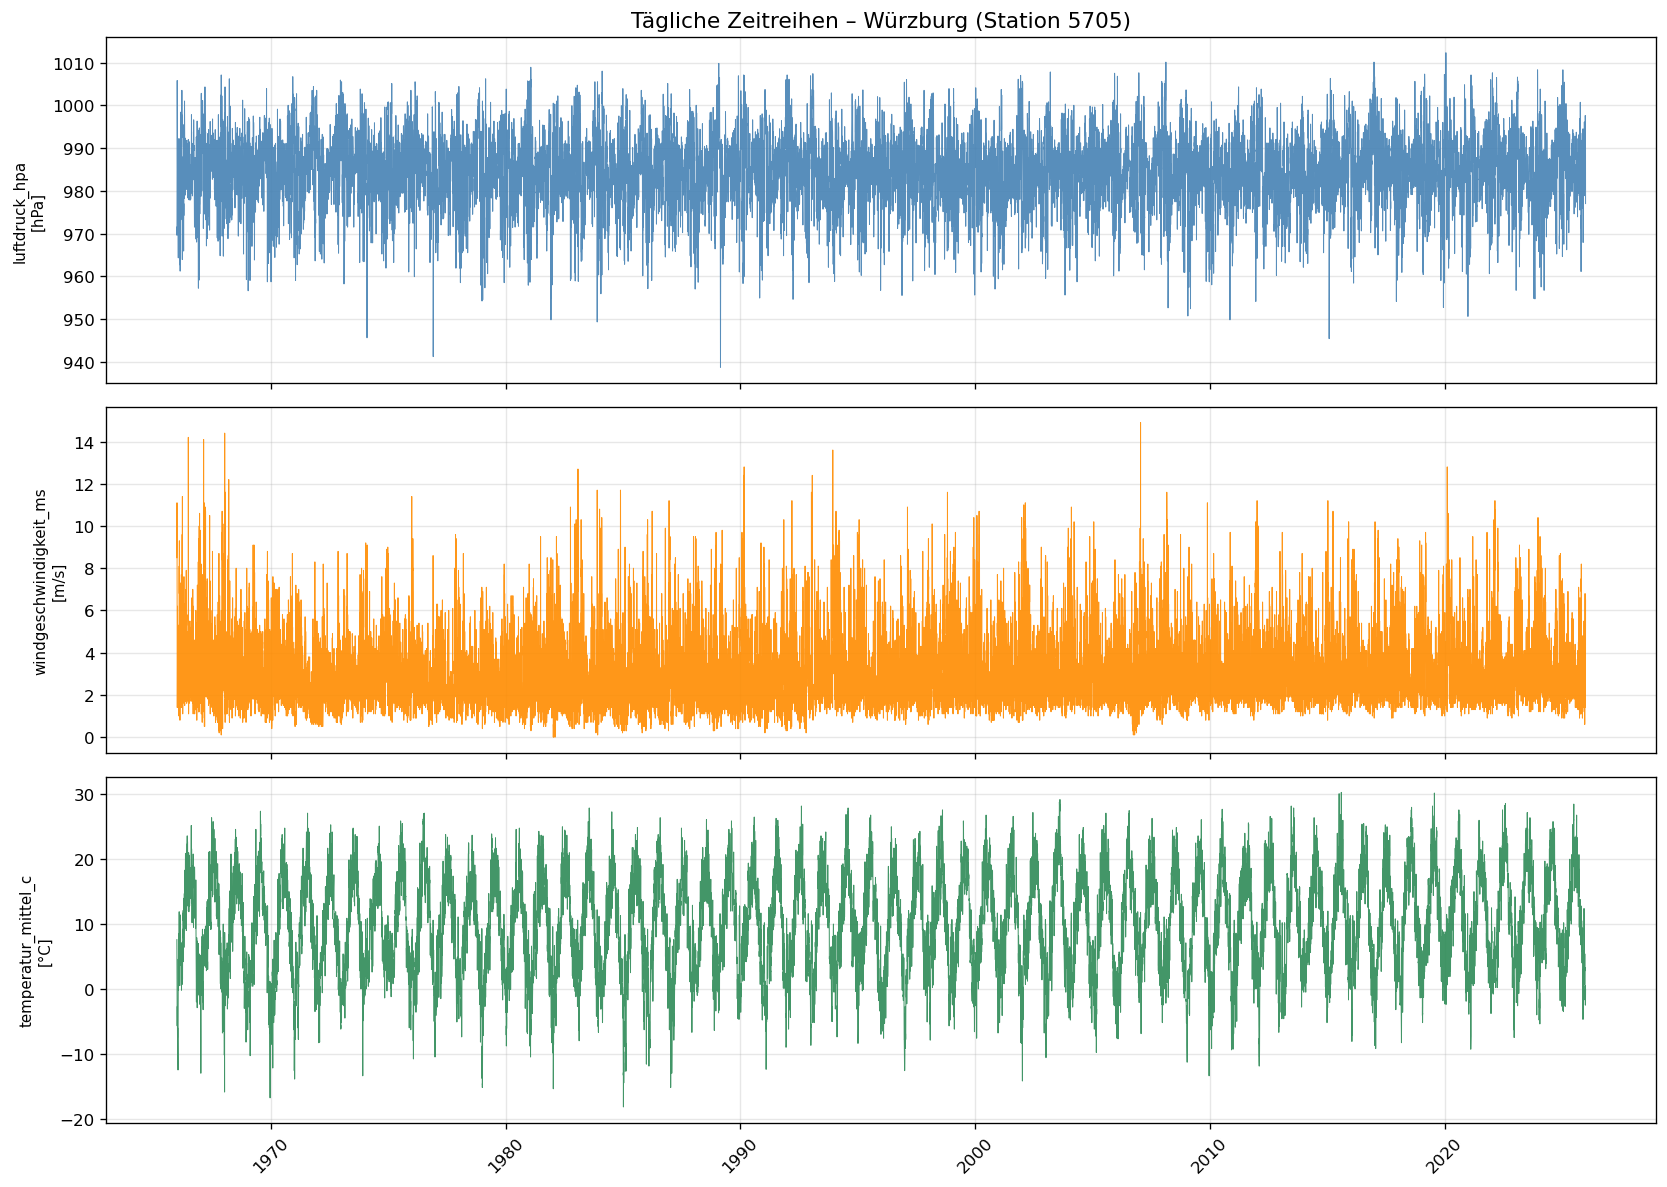


Korrelationsmatrix (Pearson):
                        luftdruck_hpa  windgeschwindigkeit_ms  \
luftdruck_hpa                   1.000                  -0.334   
windgeschwindigkeit_ms         -0.334                   1.000   
temperatur_mittel_c            -0.044                  -0.128   

                        temperatur_mittel_c  
luftdruck_hpa                        -0.044  
windgeschwindigkeit_ms               -0.128  
temperatur_mittel_c                   1.000  


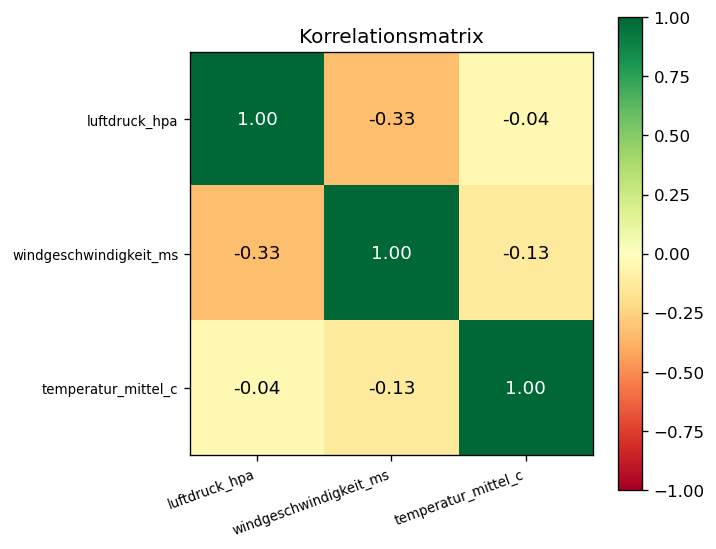

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    ax.plot(df.index, df[col], lw=0.6, color=farbe, alpha=0.9)
    ax.set_ylabel(f'{col}\n[{einheit}]', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Tägliche Zeitreihen – Würzburg (Station 5705)', fontsize=13)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_01_zeitreihen.png'), bbox_inches='tight')
plt.show()

# Korrelationsmatrix
print('\nKorrelationsmatrix (Pearson):')
corr = df.corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(VARIABLEN)))
ax.set_xticklabels(VARIABLEN, rotation=20, ha='right', fontsize=8)
ax.set_yticks(range(len(VARIABLEN)))
ax.set_yticklabels(VARIABLEN, fontsize=8)
for i in range(len(VARIABLEN)):
    for j in range(len(VARIABLEN)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
plt.colorbar(im, ax=ax)
ax.set_title('Korrelationsmatrix', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_02_korrelation.png'), bbox_inches='tight')
plt.show()

## 2. STATIONARITÄTSTESTS (ADF & KPSS)

In [22]:
print('=' * 70)
print('STATIONARITÄTSTESTS  (5%-Niveau)')
print('=' * 70)

def adf_test(serie, name):
    r = adfuller(serie.dropna(), autolag='AIC')
    ok = r[1] < 0.05
    print(f'  ADF  {name:<30}  p={r[1]:.4f}  =>  {"STATIONAER" if ok else "NICHT STATIONAER"}')
    return ok

def kpss_test(serie, name):
    r = kpss(serie.dropna(), regression='c', nlags='auto')
    ok = r[1] >= 0.05
    print(f'  KPSS {name:<30}  p={r[1]:.4f}  =>  {"STATIONAER" if ok else "NICHT STATIONAER"}')
    return ok

stationaer_niveau = {}
print('\n--- Niveau ---')
for col in VARIABLEN:
    a = adf_test(df[col], col)
    k = kpss_test(df[col], col)
    stationaer_niveau[col] = (a and k)

stationaer_diff = {}
print('\n--- Erste Differenz ---')
for col in VARIABLEN:
    d1 = df[col].diff().dropna()
    a  = adf_test(d1, col + ' (d=1)')
    k  = kpss_test(d1, col + ' (d=1)')
    stationaer_diff[col] = (a and k)

d_noetig = not all(stationaer_niveau.values())
print(f'\n  => Differenzierung noetig: {d_noetig}')
print(f'     Stationaer im Niveau   : {stationaer_niveau}')

STATIONARITÄTSTESTS  (5%-Niveau)

--- Niveau ---
  ADF  luftdruck_hpa                   p=0.0000  =>  STATIONAER
  KPSS luftdruck_hpa                   p=0.1000  =>  STATIONAER
  ADF  windgeschwindigkeit_ms          p=0.0000  =>  STATIONAER
  KPSS windgeschwindigkeit_ms          p=0.0305  =>  NICHT STATIONAER
  ADF  temperatur_mittel_c             p=0.0000  =>  STATIONAER
  KPSS temperatur_mittel_c             p=0.1000  =>  STATIONAER

--- Erste Differenz ---
  ADF  luftdruck_hpa (d=1)             p=0.0000  =>  STATIONAER
  KPSS luftdruck_hpa (d=1)             p=0.1000  =>  STATIONAER
  ADF  windgeschwindigkeit_ms (d=1)    p=0.0000  =>  STATIONAER
  KPSS windgeschwindigkeit_ms (d=1)    p=0.1000  =>  STATIONAER
  ADF  temperatur_mittel_c (d=1)       p=0.0000  =>  STATIONAER
  KPSS temperatur_mittel_c (d=1)       p=0.1000  =>  STATIONAER

  => Differenzierung noetig: True
     Stationaer im Niveau   : {'luftdruck_hpa': True, 'windgeschwindigkeit_ms': False, 'temperatur_mittel_c': True}


## 3. TRANSFORMATION ZUR STATIONARITÄT

  1-fache Differenzierung angewendet.
  Beobachtungen nach Transformation: 21,915
  Integrationsordnung d = 1


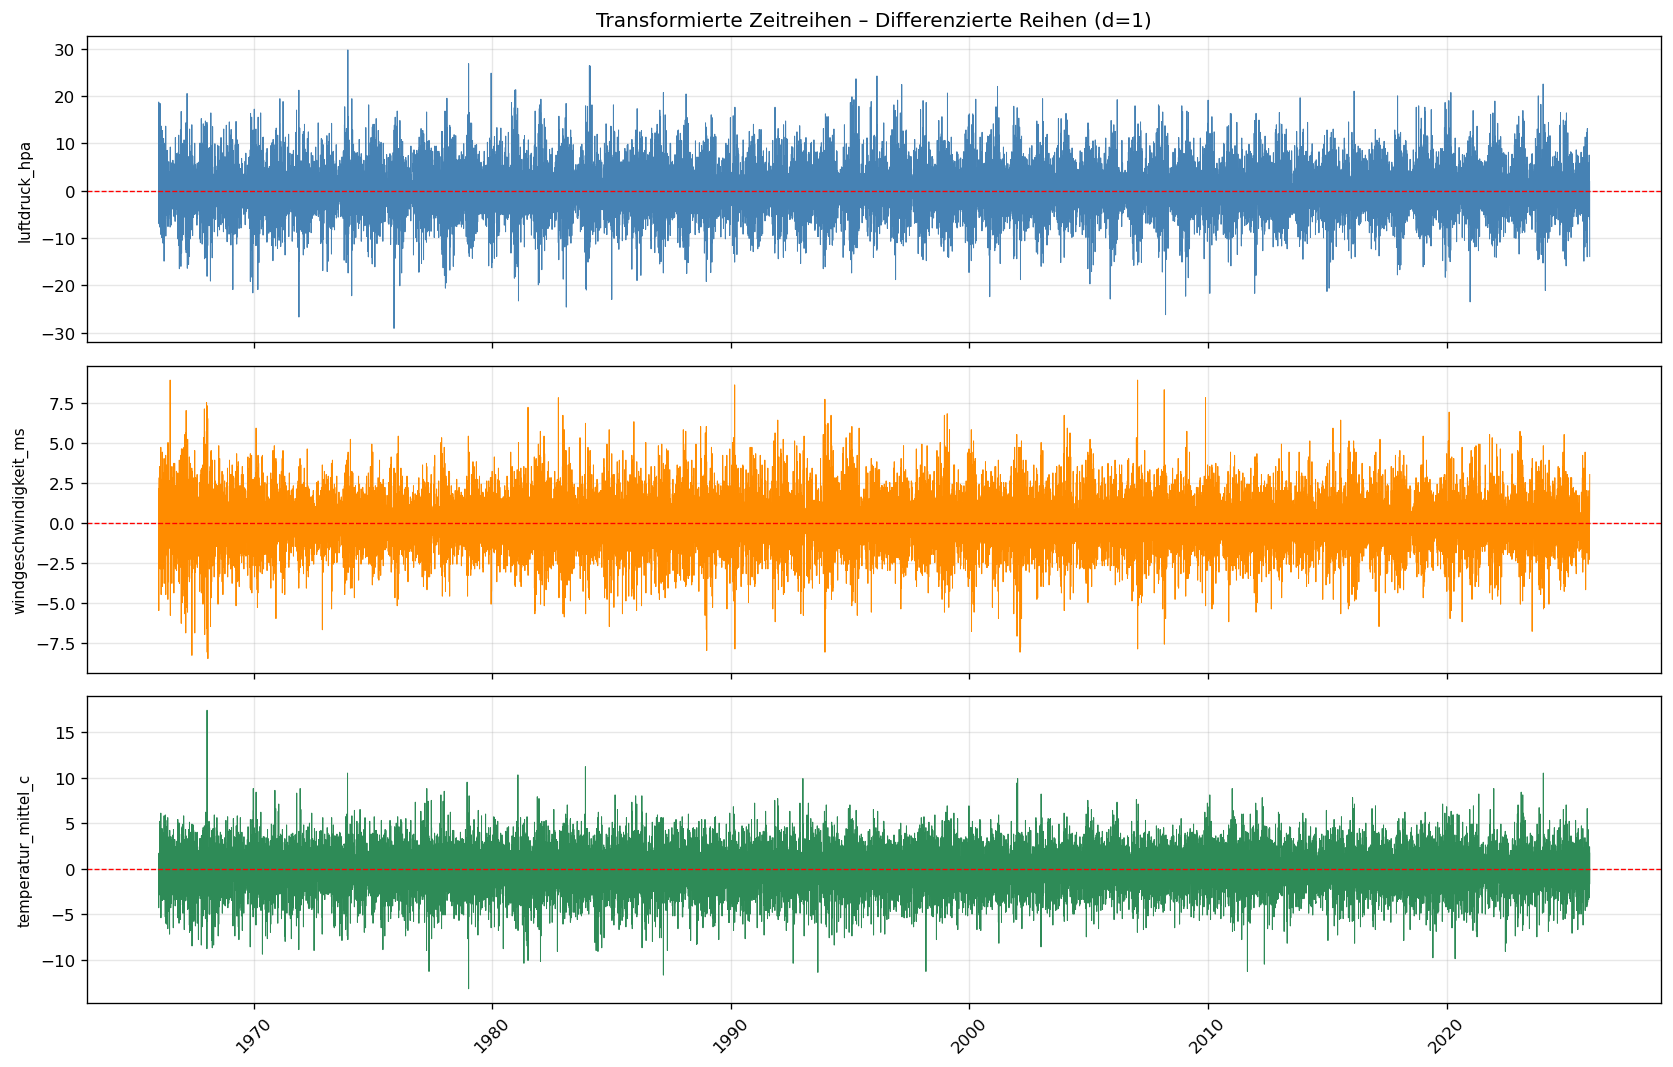

In [23]:
if d_noetig:
    df_stat = df.diff().dropna()
    d_VAR   = 1
    print('  1-fache Differenzierung angewendet.')
else:
    df_stat = df.copy()
    d_VAR   = 0
    print('  Keine Differenzierung noetig – Niveau wird verwendet.')

print(f'  Beobachtungen nach Transformation: {len(df_stat):,}')
print(f'  Integrationsordnung d = {d_VAR}')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
titel  = 'Differenzierte Reihen (d=1)' if d_VAR else 'Niveau-Reihen (d=0)'
farben = ['steelblue', 'darkorange', 'seagreen']

for ax, col, farbe in zip(axes, VARIABLEN, farben):
    ax.plot(df_stat.index, df_stat[col], lw=0.6, color=farbe)
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Transformierte Zeitreihen – {titel}', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_03_transformation.png'), bbox_inches='tight')
plt.show()

## 4. LAG-SELEKTION

In [24]:
print('=' * 70)
print('LAG-SELEKTION – VAR(p)')
print('=' * 70)

modell_var = VAR(df_stat)
lag_auswahl = modell_var.select_order(maxlags=5)
print(lag_auswahl.summary())

p_aic  = int(lag_auswahl.aic)  if int(lag_auswahl.aic)  > 0 else 1
p_bic  = int(lag_auswahl.bic)  if int(lag_auswahl.bic)  > 0 else 1

print(f'  AIC -> p = {p_aic}')
print(f'  BIC -> p = {p_bic}')

# Sparsamster Kandidat (analog zur ARIMA-Modellselektion)
if p_aic == p_bic:
    p_final = p_aic
    grund = 'AIC und BIC einig'
elif p_bic < p_aic:
    p_final = p_bic
    grund = f'BIC sparsamer ({p_bic} Lags) vs. AIC ({p_aic} Lags)'
else:
    p_final = p_aic
    grund = f'AIC sparsamer ({p_aic} Lags) vs. BIC ({p_bic} Lags)'

p_final = max(p_final, 1)
print(f'\n  => Gewaaehltes Modell: VAR({p_final})  [{grund}]')

LAG-SELEKTION – VAR(p)
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       5.701       5.702       299.2       5.702
1       5.578       5.582       264.5       5.579
2       5.446       5.454       231.8       5.449
3       5.389       5.400       219.0       5.392
4       5.352       5.366       211.0       5.356
5      5.323*      5.340*      204.9*      5.328*
-------------------------------------------------
  AIC -> p = 5
  BIC -> p = 5

  => Gewaaehltes Modell: VAR(5)  [AIC und BIC einig]


## 5. MODELLSCHÄTZUNG

In [25]:
print('=' * 70)
print(f'VAR({p_final})-MODELL SCHAETZEN')
print('=' * 70)

fit_var = modell_var.fit(p_final)
print(fit_var.summary())

VAR(5)-MODELL SCHAETZEN
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     18:20:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    5.34020
Nobs:                     21910.0    HQIC:                   5.32839
Log likelihood:          -151529.    FPE:                    204.933
AIC:                      5.32268    Det(Omega_mle):         204.484
--------------------------------------------------------------------
Results for equation luftdruck_hpa
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                            -0.000881         0.033050           -0.027           0.979
L1.luftdruck_hpa                  0.140586         0.007212           19.

## 6. RESIDUENDIAGNOSE

RESIDUENDIAGNOSE

  Durbin-Watson (Wert nahe 2 = keine Autokorrelation):
    luftdruck_hpa                   : 2.0172
    windgeschwindigkeit_ms          : 2.0280
    temperatur_mittel_c             : 2.0115

  Portmanteau-Test (H0: keine Autokorrelation in Residuen):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         1917.          61.66   0.000 45
----------------------------------------

  Normalitaetstest (Jarque-Bera):
    luftdruck_hpa                   : JB=3006.89  p=0.0000  => H0 ABGELEHNT
    windgeschwindigkeit_ms          : JB=3837.37  p=0.0000  => H0 ABGELEHNT
    temperatur_mittel_c             : JB=830.22  p=0.0000  => H0 ABGELEHNT


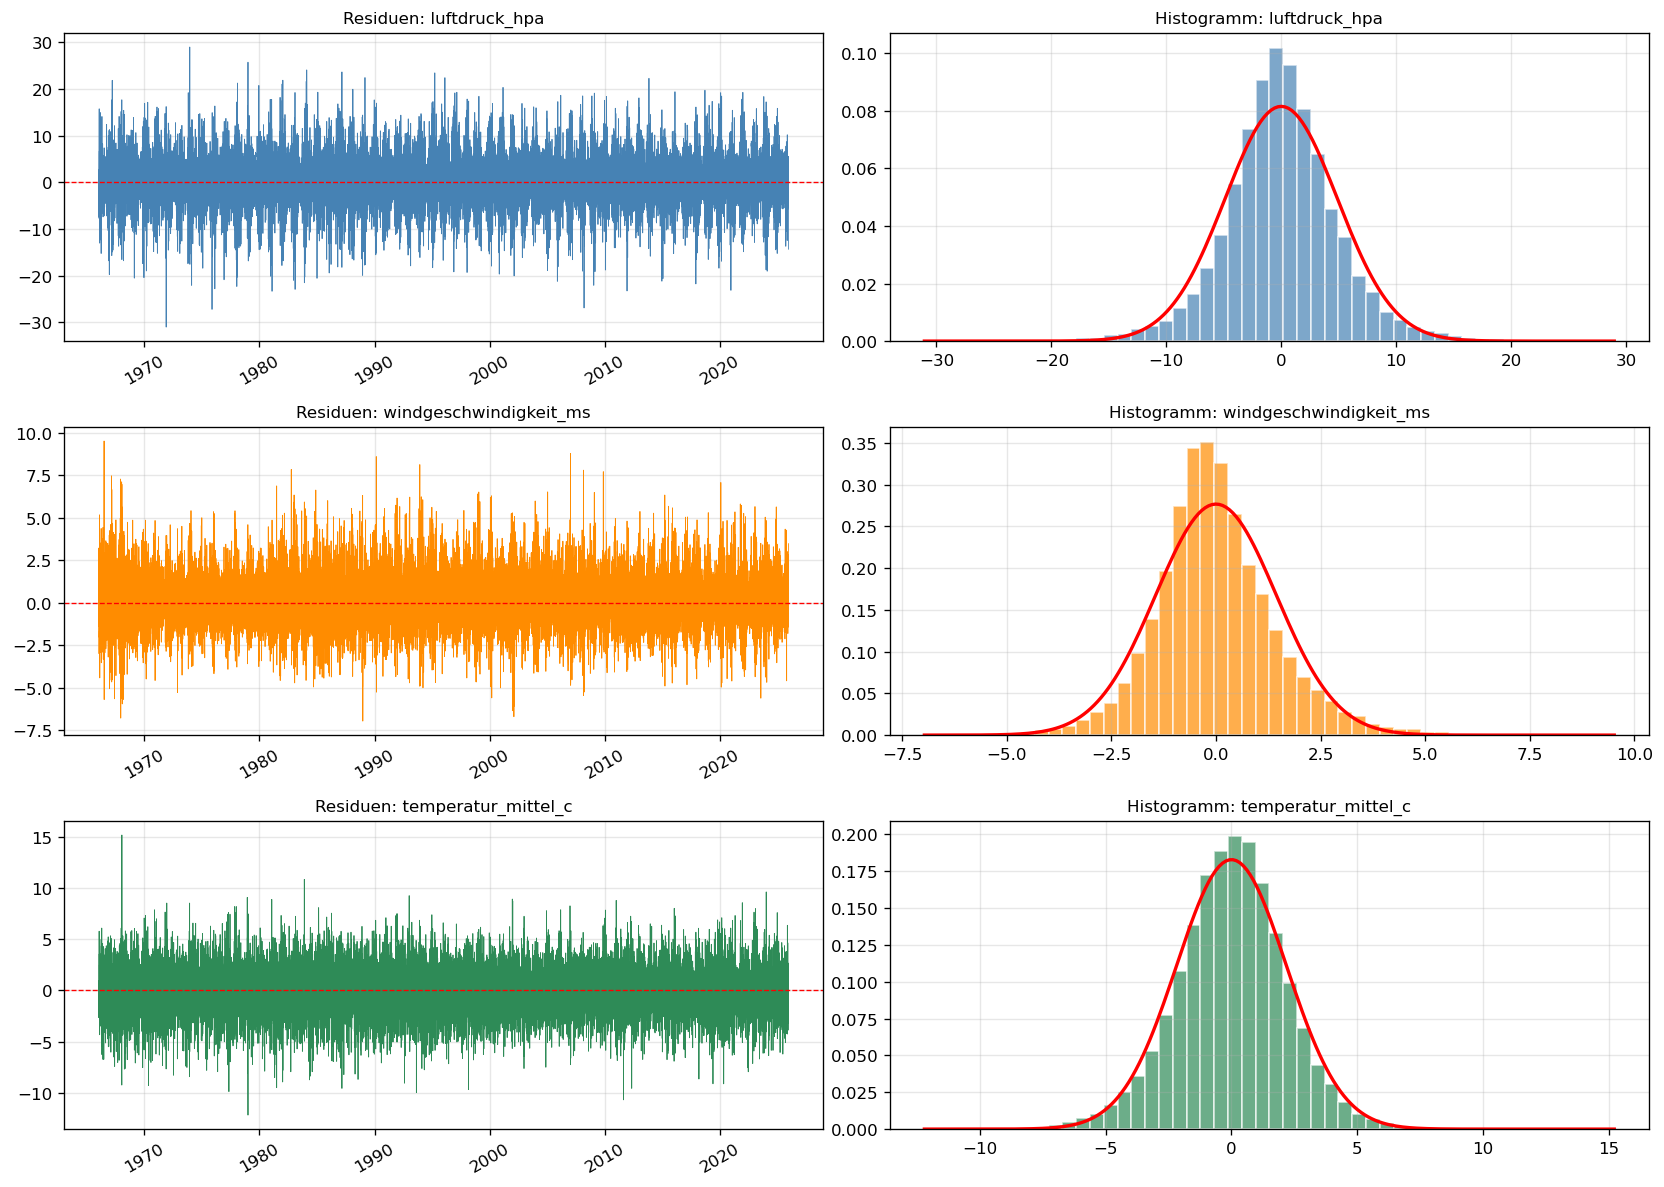

In [26]:
print('=' * 70)
print('RESIDUENDIAGNOSE')
print('=' * 70)

residuen = pd.DataFrame(fit_var.resid, columns=VARIABLEN,
                        index=df_stat.index[p_final:])

print('\n  Durbin-Watson (Wert nahe 2 = keine Autokorrelation):')
for col in VARIABLEN:
    dw = durbin_watson(residuen[col])
    print(f'    {col:<32}: {dw:.4f}')

print('\n  Portmanteau-Test (H0: keine Autokorrelation in Residuen):')
pt = fit_var.test_whiteness(nlags=10, signif=0.05)
print(pt.summary())

print('\n  Normalitaetstest (Jarque-Bera):')
for col in VARIABLEN:
    jb, p_jb = stats.jarque_bera(residuen[col].dropna())
    entscheid = 'nicht abgelehnt' if p_jb > 0.05 else 'ABGELEHNT'
    print(f'    {col:<32}: JB={jb:.2f}  p={p_jb:.4f}  => H0 {entscheid}')

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
farben = ['steelblue', 'darkorange', 'seagreen']

for row, (col, farbe) in enumerate(zip(VARIABLEN, farben)):
    res = residuen[col].dropna()
    axes[row, 0].plot(res.index, res.values, lw=0.5, color=farbe)
    axes[row, 0].axhline(0, color='red', ls='--', lw=0.8)
    axes[row, 0].set_title(f'Residuen: {col}', fontsize=10)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[row, 0].xaxis.set_major_locator(mdates.YearLocator(10))
    axes[row, 0].tick_params(axis='x', rotation=30)
    axes[row, 1].hist(res, bins=50, color=farbe, alpha=0.7, density=True, edgecolor='white')
    x = np.linspace(res.min(), res.max(), 200)
    axes[row, 1].plot(x, stats.norm.pdf(x, res.mean(), res.std()), 'r-', lw=2)
    axes[row, 1].set_title(f'Histogramm: {col}', fontsize=10)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_04_residuen.png'), bbox_inches='tight')
plt.show()

## 7. GRANGER-KAUSALITÄT

In [27]:
print('=' * 70)
print('GRANGER-KAUSALITAET  (H0: X verursacht Y NICHT)')
print('=' * 70)
print(f'  Lag p={p_final}, Signifikanzniveau 5%\n')

for ursache in VARIABLEN:
    for wirkung in VARIABLEN:
        if ursache == wirkung:
            continue
        gc  = fit_var.test_causality(wirkung, [ursache], kind='f', signif=0.05)
        p   = gc.pvalue
        sig = '**' if p < 0.01 else '*' if p < 0.05 else '  '
        ent = 'Kausalitaet JA' if p < 0.05 else 'keine Kausalitaet'
        print(f'  {ursache:<28} -> {wirkung:<28}  p={p:.4f}  {sig}  {ent}')

GRANGER-KAUSALITAET  (H0: X verursacht Y NICHT)
  Lag p=5, Signifikanzniveau 5%

  luftdruck_hpa                -> windgeschwindigkeit_ms        p=0.0000  **  Kausalitaet JA
  luftdruck_hpa                -> temperatur_mittel_c           p=0.0000  **  Kausalitaet JA
  windgeschwindigkeit_ms       -> luftdruck_hpa                 p=0.0000  **  Kausalitaet JA
  windgeschwindigkeit_ms       -> temperatur_mittel_c           p=0.0000  **  Kausalitaet JA
  temperatur_mittel_c          -> luftdruck_hpa                 p=0.0000  **  Kausalitaet JA
  temperatur_mittel_c          -> windgeschwindigkeit_ms        p=0.0000  **  Kausalitaet JA


## 8. IMPULS-ANTWORT-ANALYSE (IRF) & VARIANZDEKOMPOSITION (FEVD)

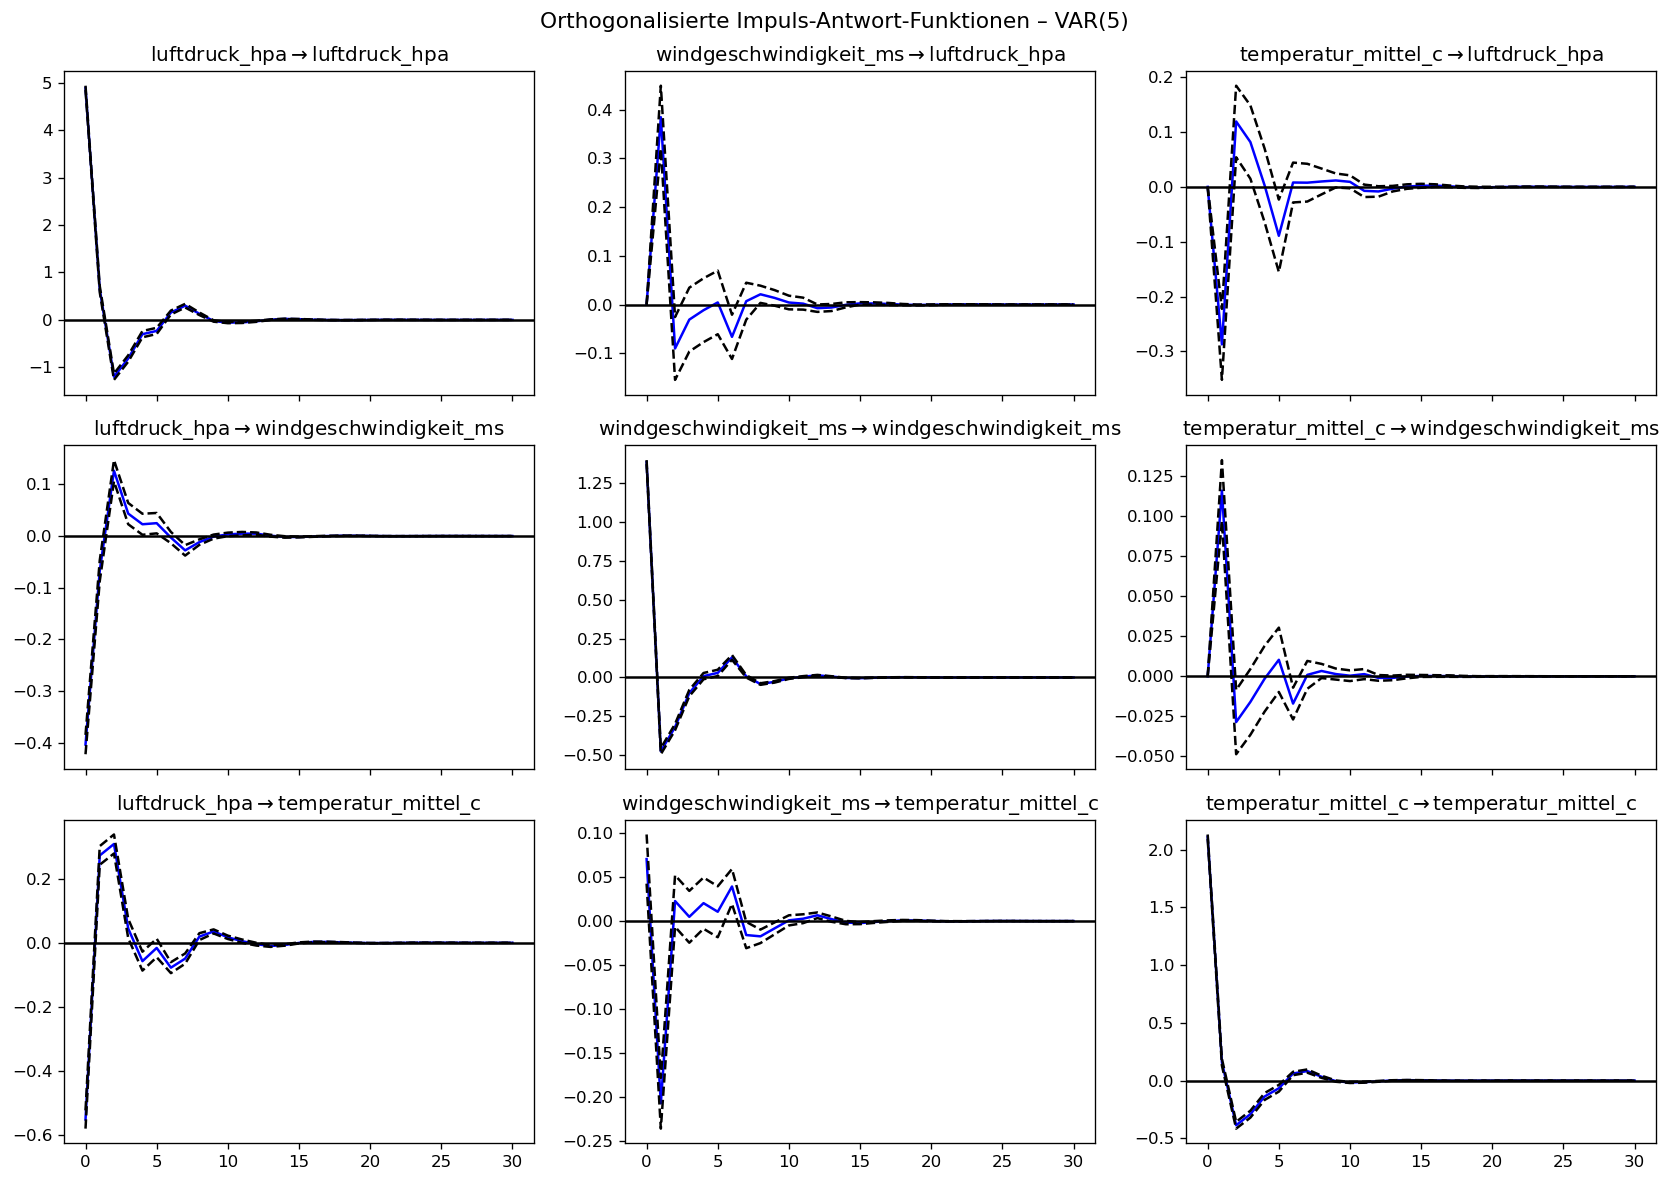

[Abbildung gespeichert: VAR_05_irf.png]


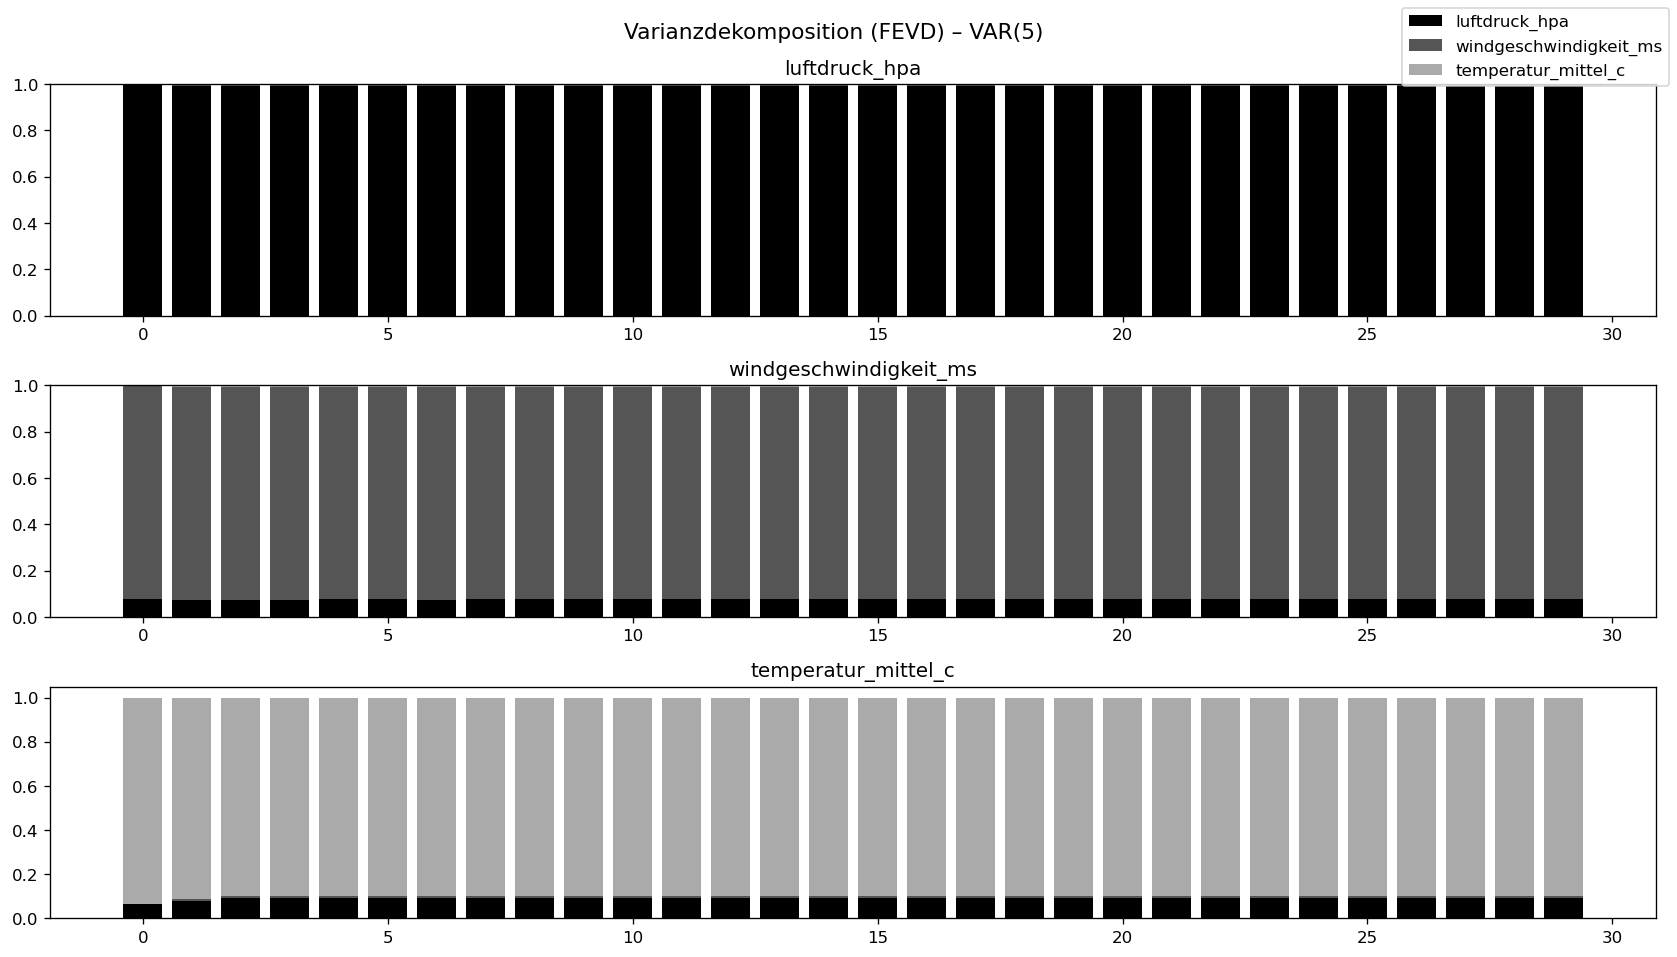

[Abbildung gespeichert: VAR_06_fevd.png]

  FEVD-Zusammenfassung (nach 10 Perioden):
FEVD for luftdruck_hpa
      luftdruck_hpa  windgeschwindigkeit_ms  temperatur_mittel_c
0          1.000000                0.000000             0.000000
1          0.990638                0.006011             0.003351
2          0.990305                0.005987             0.003709
3          0.990262                0.005872             0.003866
4          0.990290                0.005857             0.003853
5          0.990016                0.005845             0.004139
6          0.989860                0.006002             0.004137
7          0.989890                0.005984             0.004126
8          0.989877                0.005996             0.004127
9          0.989865                0.006003             0.004132
10         0.989863                0.006003             0.004134
11         0.989862                0.006002             0.004136
12         0.989858                0.006004    

In [28]:
# Orthogonalisierte IRF (Cholesky)
irf = fit_var.irf(periods=30)
fig = irf.plot(orth=True, figsize=(14, 10))
fig.suptitle(f'Orthogonalisierte Impuls-Antwort-Funktionen – VAR({p_final})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_05_irf.png'), bbox_inches='tight')
plt.show()
print('[Abbildung gespeichert: VAR_05_irf.png]')

# FEVD
fevd = fit_var.fevd(periods=30)
fig  = fevd.plot(figsize=(14, 8))
plt.suptitle(f'Varianzdekomposition (FEVD) – VAR({p_final})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_06_fevd.png'), bbox_inches='tight')
plt.show()
print('[Abbildung gespeichert: VAR_06_fevd.png]')

print('\n  FEVD-Zusammenfassung (nach 10 Perioden):')
print(fevd.summary())

## 9. TRAIN / VAL / TEST-SPLIT (70/15/15) & MODELL-EVALUATION

TRAIN/VAL/TEST-SPLIT (70/15/15)
  Gesamt     : 21,915
  Train      : 15,340  (1966-01-02 – 2008-01-01)
  Validation : 3,287   (2008-01-02 – 2016-12-31)
  Test       : 3,288   (2017-01-01 – 2026-01-01)

  Test-Set-Metriken (Multi-Step-Prognose):
  Variable                             RMSE      MAE     MAPE
  ------------------------------------------------------------
  luftdruck_hpa                      5.1411   3.8960      nan
  windgeschwindigkeit_ms             1.4767   1.0770      nan
  temperatur_mittel_c                2.2031   1.6941      nan


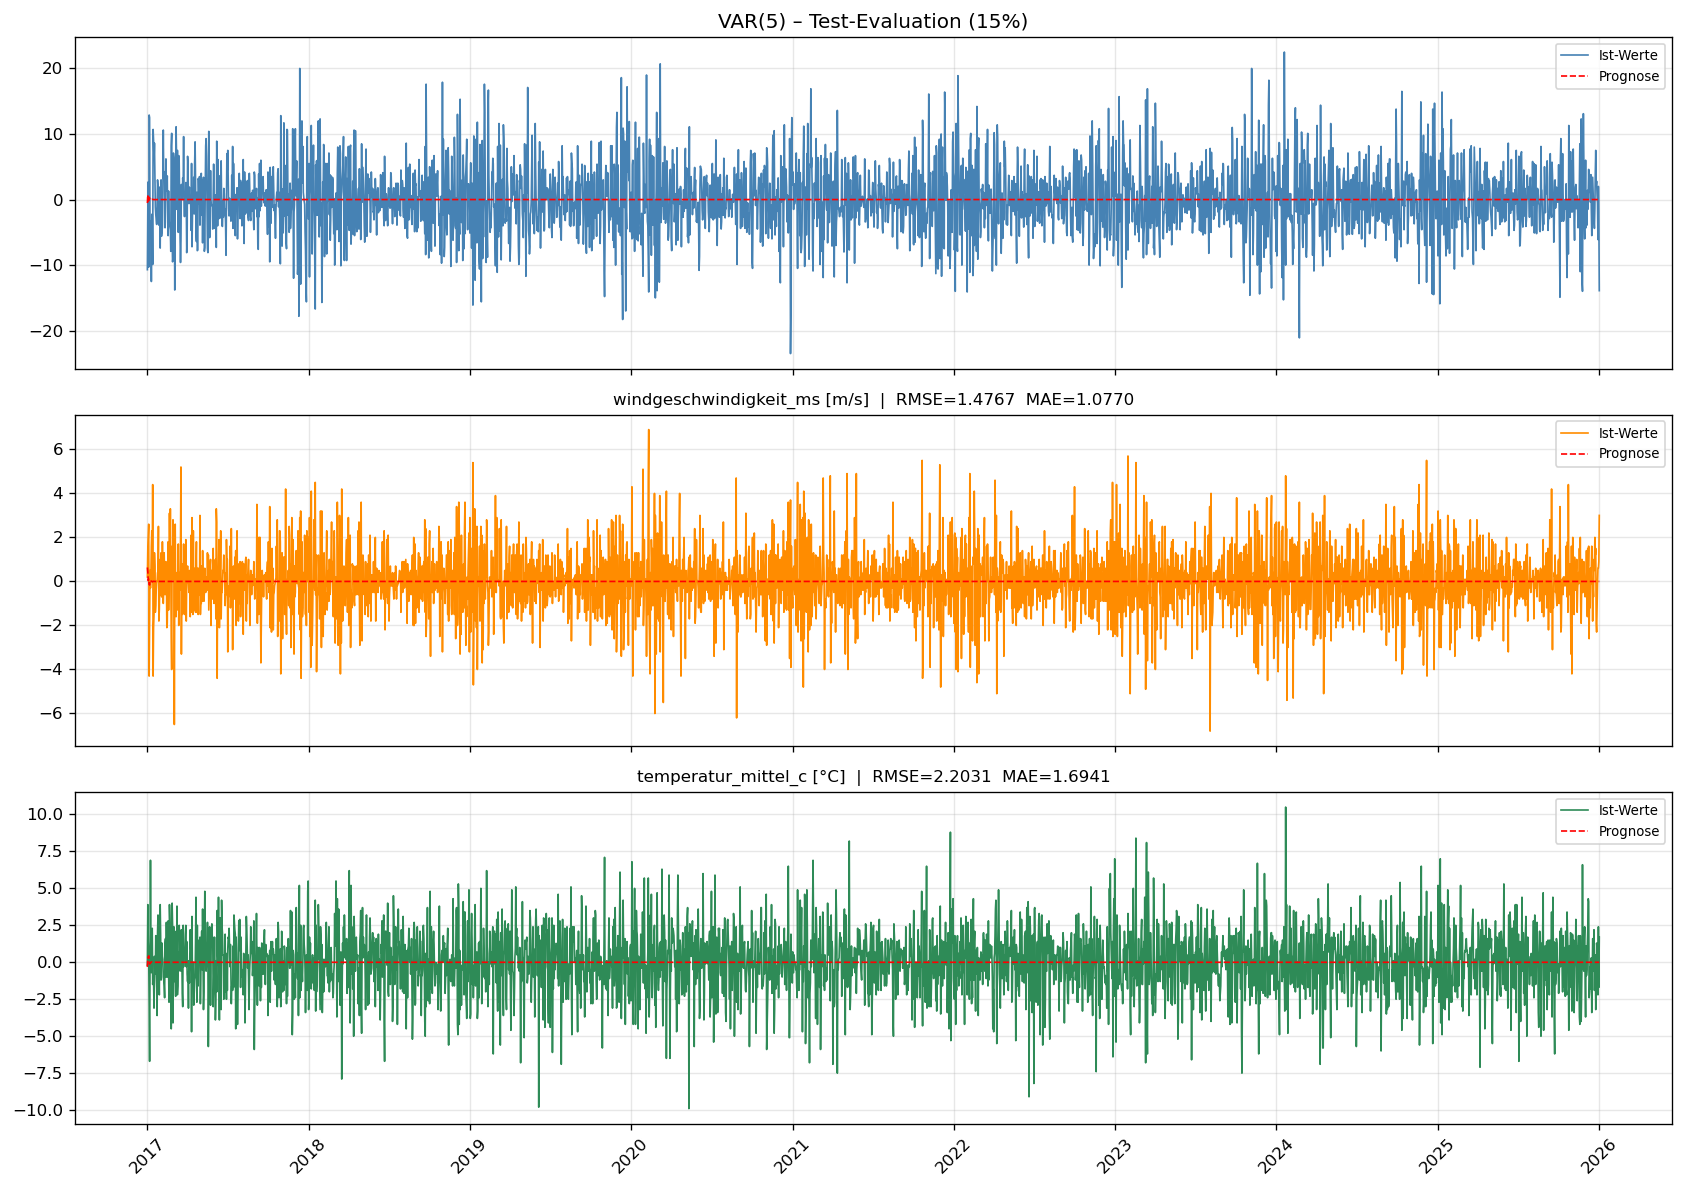

In [29]:
print('=' * 70)
print('TRAIN/VAL/TEST-SPLIT (70/15/15)')
print('=' * 70)

n         = len(df_stat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_stat.iloc[:train_end]
df_val   = df_stat.iloc[train_end:val_end]
df_test  = df_stat.iloc[val_end:]

print(f'  Gesamt     : {n:,}')
print(f'  Train      : {len(df_train):,}  ({df_train.index[0].date()} – {df_train.index[-1].date()})')
print(f'  Validation : {len(df_val):,}   ({df_val.index[0].date()} – {df_val.index[-1].date()})')
print(f'  Test       : {len(df_test):,}   ({df_test.index[0].date()} – {df_test.index[-1].date()})')

fit_train = VAR(df_train).fit(p_final)
n_test    = len(df_test)
fc_arr    = fit_train.forecast(df_train.values[-p_final:], steps=n_test)
fc_test   = pd.DataFrame(fc_arr, index=df_test.index, columns=VARIABLEN)

print('\n  Test-Set-Metriken (Multi-Step-Prognose):')
print(f'  {"Variable":<32} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('  ' + '-' * 60)

metriken_test = {}
for col in VARIABLEN:
    ist  = df_test[col].values
    prog = fc_test[col].values
    rmse = np.sqrt(mean_squared_error(ist, prog))
    mae  = mean_absolute_error(ist, prog)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist - prog) / np.where(ist == 0, np.nan, ist))) * 100
    metriken_test[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f'  {col:<32} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
farben = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    ax.plot(df_test.index, df_test[col], color=farbe, lw=1.0, label='Ist-Werte')
    ax.plot(fc_test.index, fc_test[col], color='red', lw=1.0, ls='--', label='Prognose')
    m = metriken_test[col]
    ax.set_title(f'{col} [{einheit}]  |  RMSE={m["RMSE"]:.4f}  MAE={m["MAE"]:.4f}', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[0].set_title(f'VAR({p_final}) – Test-Evaluation (15%)', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_07_test_evaluation.png'), bbox_inches='tight')
plt.show()

## 10. TIME-SERIES-CROSS-VALIDATION (5-Fold)

In [30]:
print('=' * 70)
print('5-FOLD TIME-SERIES-CROSS-VALIDATION')
print('=' * 70)

CV_FENSTER  = 1095
CV_TESTSIZE = 30
N_SPLITS    = 5

df_cv  = df_train.iloc[-min(CV_FENSTER, len(df_train)):]
tscv   = TimeSeriesSplit(n_splits=N_SPLITS, test_size=CV_TESTSIZE)

print(f'  CV-Pool    : letzte {len(df_cv)} Tage der Trainingsdaten')
print(f'  Fold-Groesse: {CV_TESTSIZE} Tage  |  Folds: {N_SPLITS}\n')

fold_records = []
for fold, (idx_tr, idx_te) in enumerate(tscv.split(df_cv)):
    cv_tr = df_cv.iloc[idx_tr]
    cv_te = df_cv.iloc[idx_te]
    fc    = VAR(cv_tr).fit(p_final).forecast(cv_tr.values[-p_final:], steps=len(cv_te))
    fc_cv = pd.DataFrame(fc, index=cv_te.index, columns=VARIABLEN)
    row   = {'Fold': fold + 1}
    for col in VARIABLEN:
        row[f'RMSE_{col}'] = np.sqrt(mean_squared_error(cv_te[col].values, fc_cv[col].values))
        row[f'MAE_{col}']  = mean_absolute_error(cv_te[col].values, fc_cv[col].values)
    fold_records.append(row)

cv_res = pd.DataFrame(fold_records).set_index('Fold')

header = f'  {"Fold":<6}'
for col in VARIABLEN:
    header += f'  {"RMSE_" + col[:6]:<12}  {"MAE_" + col[:6]:<12}'
print(header)
print('  ' + '-' * (6 + 28 * len(VARIABLEN)))
for fold, row in cv_res.iterrows():
    line = f'  {fold:<6}'
    for col in VARIABLEN:
        line += f'  {row[f"RMSE_{col}"]:>12.4f}  {row[f"MAE_{col}"]:>12.4f}'
    print(line)
print('  ' + '-' * (6 + 28 * len(VARIABLEN)))
line = f'  {"Mittel":<6}'
for col in VARIABLEN:
    line += f'  {cv_res[f"RMSE_{col}"].mean():>12.4f}  {cv_res[f"MAE_{col}"].mean():>12.4f}'
print(line)

5-FOLD TIME-SERIES-CROSS-VALIDATION
  CV-Pool    : letzte 1095 Tage der Trainingsdaten
  Fold-Groesse: 30 Tage  |  Folds: 5

  Fold    RMSE_luftdr   MAE_luftdr    RMSE_windge   MAE_windge    RMSE_temper   MAE_temper  
  ------------------------------------------------------------------------------------------
  1             3.6601        2.9038        0.9919        0.7819        1.8861        1.4989
  2             4.8035        3.7432        1.3139        0.9408        1.9828        1.6219
  3             4.0687        2.9715        1.0839        0.8142        2.0350        1.6064
  4             5.3960        4.4915        1.6357        1.3016        1.8663        1.4866
  5             7.2768        5.3454        1.6098        1.3318        1.8245        1.2787
  ------------------------------------------------------------------------------------------
  Mittel        5.0410        3.8911        1.3270        1.0341        1.9189        1.4985


## 11. 10-TAGE-PROGNOSE

10-TAGE-PROGNOSE (Gesamtmodell)

  Prognose ab 02.01.2026:
  Datum                    luftdruck_hpa  windgeschwindigkeit_ms     temperatur_mittel_c
  --------------------------------------------------------------------------------------
  02.01.2026                     -0.5059                 -0.9681                 -0.9796
  03.01.2026                      4.1437                 -1.0531                 -0.7564
  04.01.2026                      2.1050                 -0.2362                 -0.0705
  05.01.2026                      0.7936                  0.0272                  0.2890
  06.01.2026                      0.4933                  0.0892                  0.0718
  07.01.2026                     -0.6910                  0.2254                  0.2477
  08.01.2026                     -0.8849                  0.0498                  0.0807
  09.01.2026                     -0.2599                 -0.0682                 -0.1064
  10.01.2026                      0.1434           

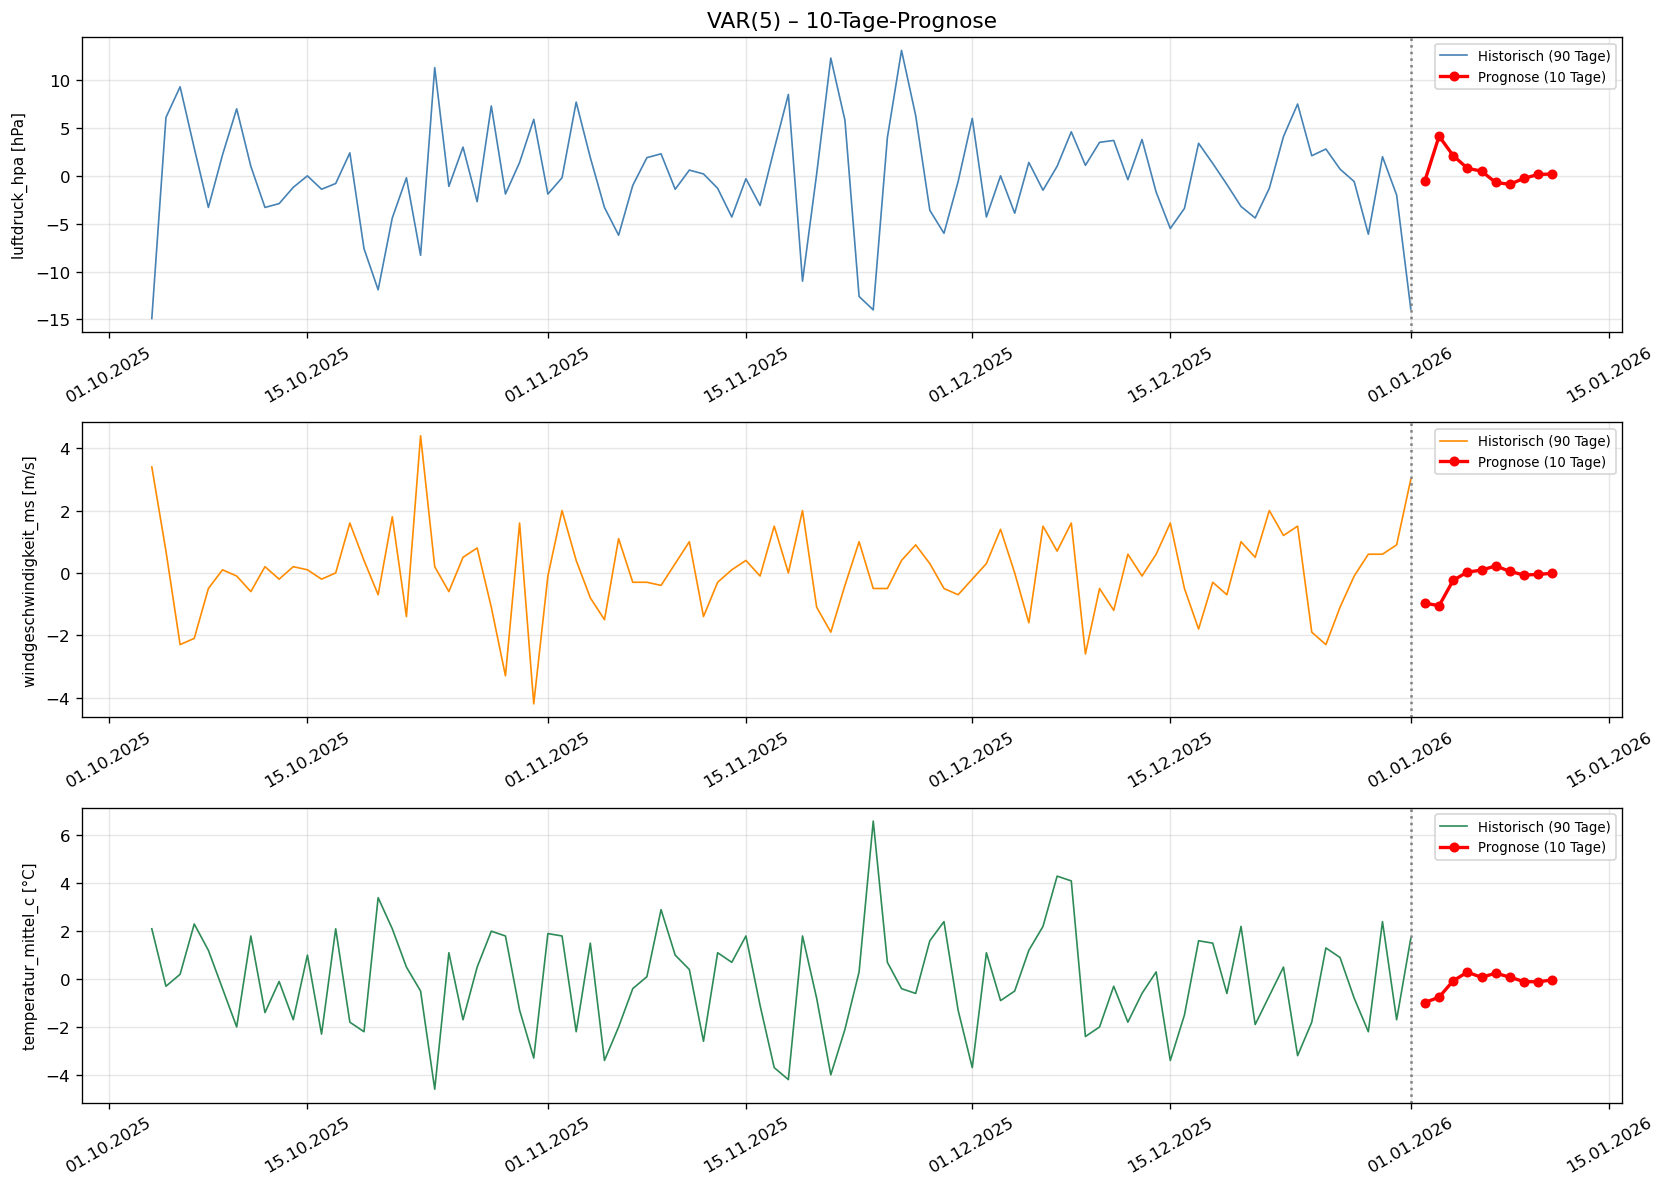

In [31]:
print('=' * 70)
print('10-TAGE-PROGNOSE (Gesamtmodell)')
print('=' * 70)

N_PROGNOSE  = 10
fc_arr_prog = fit_var.forecast(df_stat.values[-p_final:], steps=N_PROGNOSE)
prog_index  = pd.date_range(df_stat.index[-1] + pd.Timedelta(days=1),
                            periods=N_PROGNOSE, freq='D')
fc_prog     = pd.DataFrame(fc_arr_prog, index=prog_index, columns=VARIABLEN)

print(f'\n  Prognose ab {prog_index[0].strftime("%d.%m.%Y")}:')
print(f'  {"Datum":<14}', end='')
for col in VARIABLEN:
    print(f'  {col[:22]:>22}', end='')
print()
print('  ' + '-' * (14 + 24 * len(VARIABLEN)))
for d, row in fc_prog.iterrows():
    print(f'  {d.strftime("%d.%m.%Y"):<14}', end='')
    for col in VARIABLEN:
        print(f'  {row[col]:>22.4f}', end='')
    print()

n_hist = 90
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    hist = df_stat[col].iloc[-n_hist:]
    ax.plot(hist.index, hist.values, color=farbe, lw=1.0, label='Historisch (90 Tage)')
    ax.plot(fc_prog.index, fc_prog[col].values, color='red', lw=2,
            marker='o', markersize=5, label='Prognose (10 Tage)')
    ax.axvline(df_stat.index[-1], color='gray', ls=':', lw=1.5)
    ax.set_ylabel(f'{col} [{einheit}]', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    ax.tick_params(axis='x', rotation=30)

axes[0].set_title(f'VAR({p_final}) – 10-Tage-Prognose', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_08_prognose.png'), bbox_inches='tight')
plt.show()

## 11b. HOLDOUT-EVALUATION: Prognose vs. tatsächliche Werte

HOLDOUT-EVALUATION (10-Tage-Prognose vs. Ist-Werte)
  Variable                             RMSE      MAE     MAPE
  ------------------------------------------------------------
  luftdruck_hpa                      8.6391   6.4788    76.35
  windgeschwindigkeit_ms             1.6675   1.4129    93.96
  temperatur_mittel_c                3.0223   2.4738   145.18


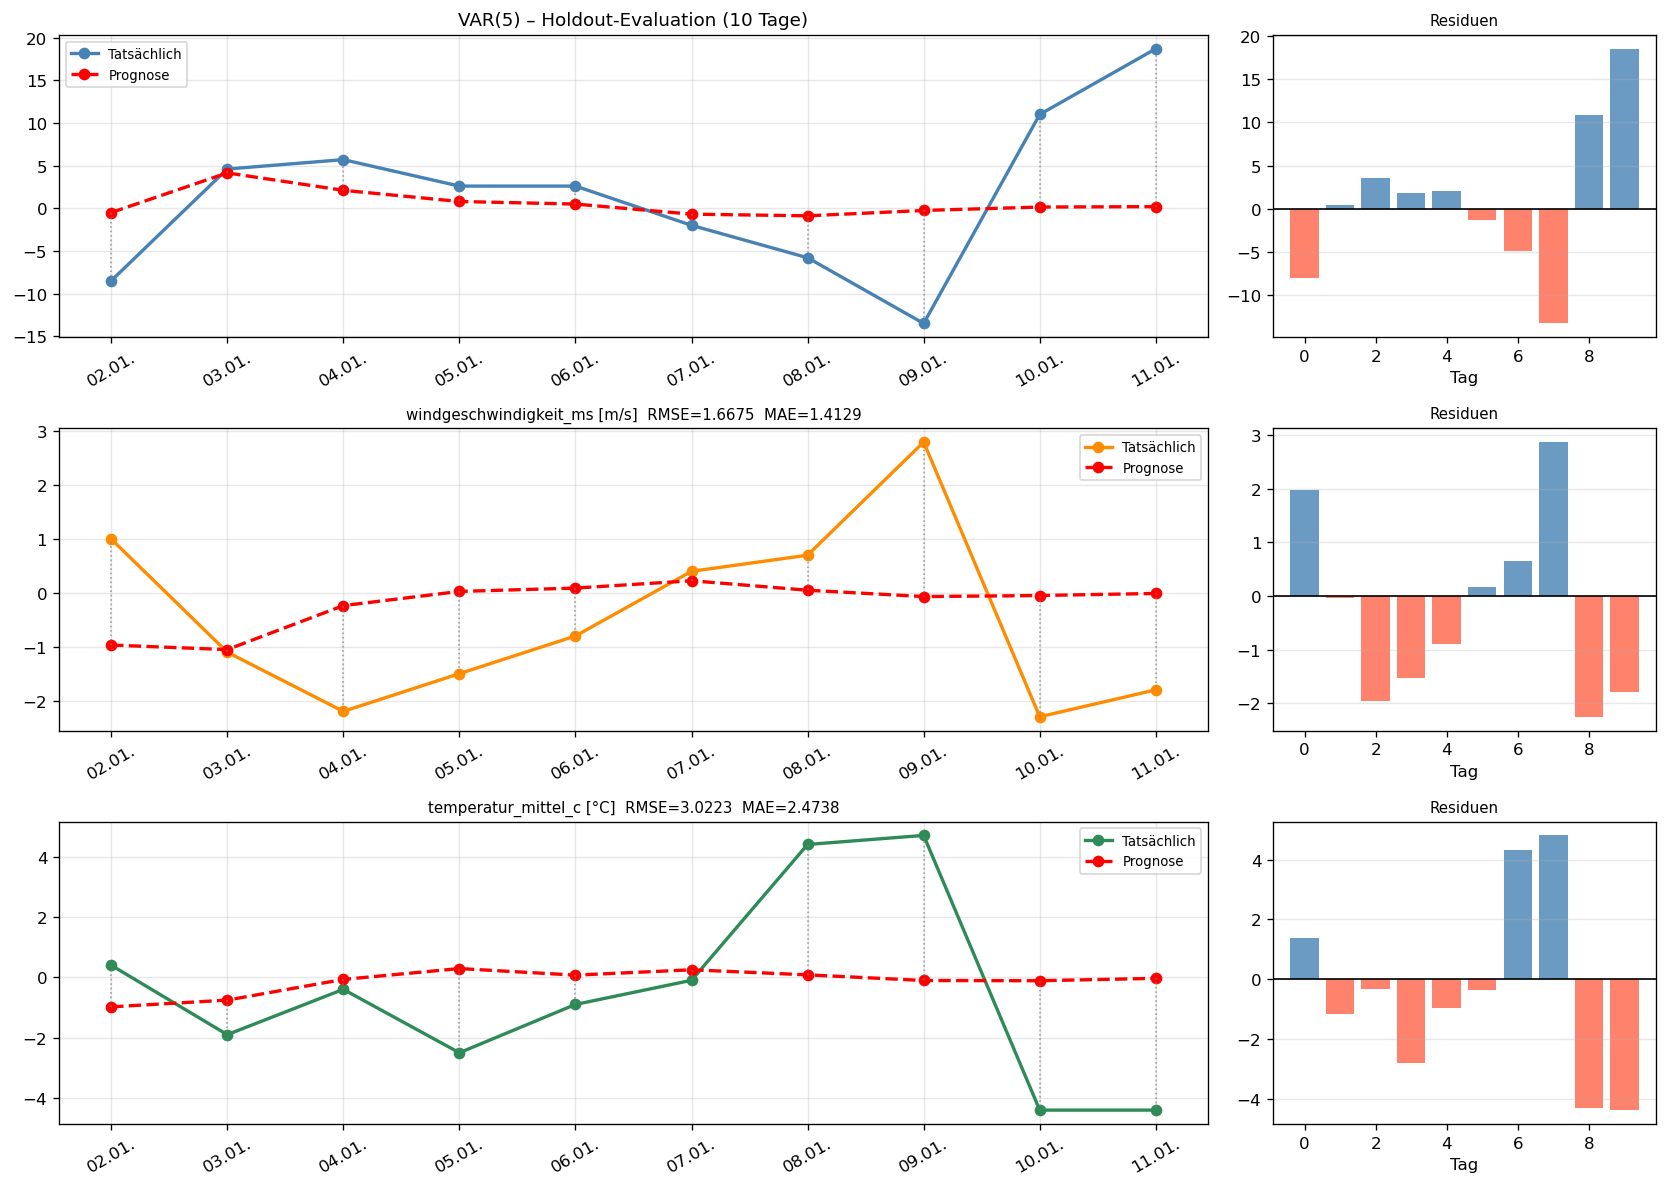

In [32]:
print('=' * 70)
print('HOLDOUT-EVALUATION (10-Tage-Prognose vs. Ist-Werte)')
print('=' * 70)

# Holdout ggf. differenzieren
if d_VAR == 1:
    df_ho_stat = pd.concat([df.iloc[[-1]], df_holdout]).diff().dropna()
else:
    df_ho_stat = df_holdout.copy()

# Forecast-Index mit Holdout abgleichen
fc_ho = fc_prog.reindex(df_ho_stat.index)

print(f'  {"Variable":<32} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('  ' + '-' * 60)
metriken_ho = {}
for col in VARIABLEN:
    ist  = df_ho_stat[col].dropna().values
    prog = fc_ho[col].dropna().values
    n    = min(len(ist), len(prog))
    if n == 0:
        continue
    ist, prog = ist[:n], prog[:n]
    rmse = np.sqrt(mean_squared_error(ist, prog))
    mae  = mean_absolute_error(ist, prog)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist - prog) / np.where(ist == 0, np.nan, ist))) * 100
    metriken_ho[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f'  {col:<32} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}')

fig, axes = plt.subplots(3, 2, figsize=(14, 10),
                          gridspec_kw={'width_ratios': [3, 1]})
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for row, (col, farbe, einheit) in enumerate(zip(VARIABLEN, farben, einheiten)):
    ist_s  = df_ho_stat[col].values
    prog_s = fc_ho[col].values
    idx    = df_ho_stat.index
    n      = min(len(ist_s), len(prog_s))
    ist_s, prog_s, idx = ist_s[:n], prog_s[:n], idx[:n]

    # Linienplot
    ax = axes[row, 0]
    ax.plot(idx, ist_s,  color=farbe, lw=2, marker='o', ms=6, label='Tatsächlich')
    ax.plot(idx, prog_s, color='red',  lw=2, marker='o', ms=6, ls='--', label='Prognose')
    for d, p, a in zip(idx, prog_s, ist_s):
        ax.plot([d, d], [p, a], color='gray', lw=1, ls=':', alpha=0.7)
    m = metriken_ho.get(col, {})
    ax.set_title(f'{col} [{einheit}]  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
    ax.tick_params(axis='x', rotation=30)

    # Residuen-Balken
    ax2 = axes[row, 1]
    res = ist_s - prog_s
    farben_bar = ['tomato' if r < 0 else 'steelblue' for r in res]
    ax2.bar(range(len(res)), res, color=farben_bar, alpha=0.8)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_title('Residuen', fontsize=9)
    ax2.set_xlabel('Tag'); ax2.grid(True, alpha=0.3, axis='y')

axes[0, 0].set_title(f'VAR({p_final}) – Holdout-Evaluation (10 Tage)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_09_holdout.png'), bbox_inches='tight')
plt.show()

## 12. BENCHMARK: VAR vs. ARIMA(1,1,2)

BENCHMARK: VAR vs. ARIMA(1,1,2) - Vergleich auf Originalskala
  ARIMA(1,1,2) ist das sparsamste Modell aus dem univariaten Vergleich.
  Hier wird geprueft, ob das multivariate VAR einen Mehrwert bietet.

  RMSE (Originalskala, Test 15 %)
  Variable                                VAR   ARIMA(1,1,2)      Delta   Besser
  ----------------------------------------------------------------------------
  luftdruck_hpa                       17.6257         8.2834    +9.3423    ARIMA
  windgeschwindigkeit_ms               2.3303         1.6890    +0.6413    ARIMA
  temperatur_mittel_c                 17.0123        14.2602    +2.7521    ARIMA

  MAE (Originalskala, Test 15 %)
  Variable                                VAR   ARIMA(1,1,2)      Delta   Besser
  ----------------------------------------------------------------------------
  luftdruck_hpa                       15.7286         6.3580    +9.3705    ARIMA
  windgeschwindigkeit_ms               1.6684         1.2410    +0.4274    ARIMA
  t

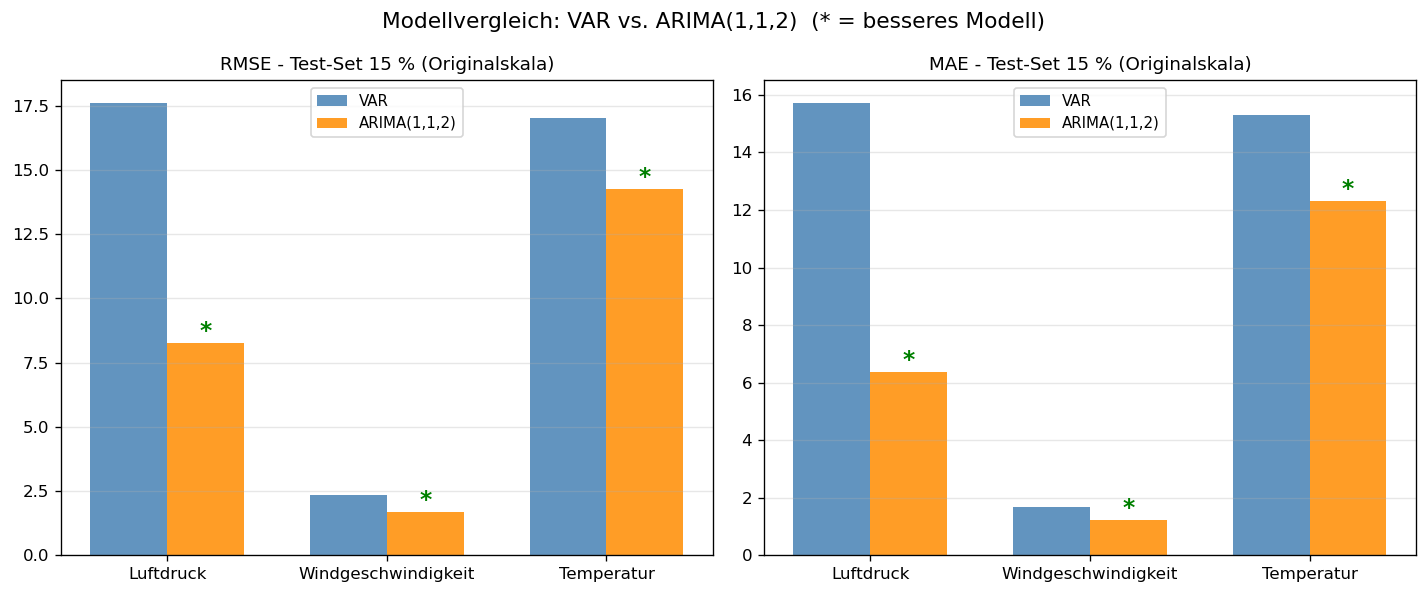

In [33]:
from statsmodels.tsa.arima.model import ARIMA as ARIMAmodel

print('=' * 70)
print('BENCHMARK: VAR vs. ARIMA(1,1,2) - Vergleich auf Originalskala')
print('=' * 70)
print('  ARIMA(1,1,2) ist das sparsamste Modell aus dem univariaten Vergleich.')
print('  Hier wird geprueft, ob das multivariate VAR einen Mehrwert bietet.')

BENCHMARK_ORDER = (1, 1, 2)

# VAR-Prognose in Originalskala zurueckrechnen
if d_VAR == 1:
    letzter_train_orig = df.loc[df_stat.index[val_end - 1]]
    fc_var_orig = fc_test.cumsum().add(letzter_train_orig.values, axis=1)
else:
    fc_var_orig = fc_test.copy()
fc_var_orig.index = df_test.index

df_test_orig = df.loc[df_test.index]

# VAR-Metriken auf Originalskala
metriken_var_orig = {}
for col in VARIABLEN:
    ist  = df_test_orig[col].values
    prog = fc_var_orig[col].values
    n    = min(len(ist), len(prog))
    rmse = np.sqrt(mean_squared_error(ist[:n], prog[:n]))
    mae  = mean_absolute_error(ist[:n], prog[:n])
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist[:n]-prog[:n]) / np.where(ist[:n]==0, np.nan, ist[:n]))) * 100
    metriken_var_orig[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# ARIMA(1,1,2)-Benchmark, identischer Trainingszeitraum
train_arima = df.loc[:df_stat.index[train_end - 1]]

metriken_arima_bm = {}
for col in VARIABLEN:
    try:
        fit_a  = ARIMAmodel(train_arima[col], order=BENCHMARK_ORDER).fit()
        fc_a   = fit_a.get_forecast(steps=len(df_test)).predicted_mean
        fc_a.index = df_test.index
        ist_a  = df_test_orig[col].values
        prog_a = fc_a.values
        n_a    = min(len(ist_a), len(prog_a))
        rmse_a = np.sqrt(mean_squared_error(ist_a[:n_a], prog_a[:n_a]))
        mae_a  = mean_absolute_error(ist_a[:n_a], prog_a[:n_a])
        with np.errstate(divide='ignore', invalid='ignore'):
            mape_a = np.mean(np.abs((ist_a[:n_a]-prog_a[:n_a]) / np.where(ist_a[:n_a]==0, np.nan, ist_a[:n_a]))) * 100
        metriken_arima_bm[col] = {'RMSE': rmse_a, 'MAE': mae_a, 'MAPE': mape_a}
    except Exception as e:
        print(f'  ARIMA-Fehler {col}: {e}')
        metriken_arima_bm[col] = {'RMSE': float('nan'), 'MAE': float('nan'), 'MAPE': float('nan')}

# Vergleichstabellen
for metrik in ['RMSE', 'MAE', 'MAPE']:
    einheit = ' %' if metrik == 'MAPE' else ''
    print(f'\n  {metrik}{einheit} (Originalskala, Test 15 %)')
    print(f'  {"Variable":<32} {"VAR":>10} {"ARIMA(1,1,2)":>14} {"Delta":>10} {"Besser":>8}')
    print('  ' + '-' * 76)
    for col in VARIABLEN:
        v = metriken_var_orig[col][metrik]
        a = metriken_arima_bm[col][metrik]
        delta = v - a
        besser = 'VAR' if v < a else 'ARIMA'
        print(f'  {col:<32} {v:>10.4f} {a:>14.4f} {delta:>+10.4f} {besser:>8}')

# Balkendiagramm
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x      = np.arange(len(VARIABLEN))
breite = 0.35
labels = [c.split('_')[0].capitalize() for c in VARIABLEN]

for ax, metrik in zip(axes, ['RMSE', 'MAE']):
    var_w   = [metriken_var_orig[c][metrik] for c in VARIABLEN]
    arima_w = [metriken_arima_bm[c][metrik] for c in VARIABLEN]
    ax.bar(x - breite/2, var_w,   breite, label='VAR',          color='steelblue',  alpha=0.85)
    ax.bar(x + breite/2, arima_w, breite, label='ARIMA(1,1,2)', color='darkorange', alpha=0.85)
    for xi, (v, a) in enumerate(zip(var_w, arima_w)):
        winner_x = xi - breite/2 if v < a else xi + breite/2
        ax.annotate('*', xy=(winner_x, min(v, a)), ha='center', va='bottom',
                    fontsize=14, color='green', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(f'{metrik} - Test-Set 15 % (Originalskala)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Modellvergleich: VAR vs. ARIMA(1,1,2)  (* = besseres Modell)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_10_benchmark.png'), bbox_inches='tight')
plt.show()

## ZUSAMMENFASSUNG

In [34]:
print('=' * 70)
print('ZUSAMMENFASSUNG - VAR-MODELL')
print('=' * 70)
print(f"""
  Datensatz      : Wuerzburg, Station 5705
  Variablen      : {', '.join(VARIABLEN)}
  Zeitraum       : {df.index[0].date()} bis {df.index[-1].date()}
  Beobachtungen  : {len(df):,} Tageswerte  |  Holdout: 10 Tage

  Integrationsordnung : d = {d_VAR}
  Gewaehltes Modell   : VAR({p_final})
""")
print('  --- Test-Set (15 %, differenzierte Skala) ---')
for col in VARIABLEN:
    m = metriken_test.get(col, {})
    print(f'  {col:<32}  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}')
print()
print('  --- Holdout (10-Tage-Prognose, differenzierte Skala) ---')
for col in VARIABLEN:
    m = metriken_ho.get(col, {})
    print(f'  {col:<32}  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}')
print()
print('  --- Benchmark RMSE: VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---')
print(f'  {"Variable":<32}  {"VAR":>10}  {"ARIMA(1,1,2)":>14}  {"Besser":>12}')
print('  ' + '-' * 72)
for col in VARIABLEN:
    v = metriken_var_orig.get(col, {}).get('RMSE', float('nan'))
    a = metriken_arima_bm.get(col, {}).get('RMSE', float('nan'))
    besser = 'VAR' if v < a else 'ARIMA(1,1,2)'
    print(f'  {col:<32}  {v:>10.4f}  {a:>14.4f}  {besser:>12}')
print()
print('  --- Benchmark MAE:  VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---')
print(f'  {"Variable":<32}  {"VAR":>10}  {"ARIMA(1,1,2)":>14}  {"Besser":>12}')
print('  ' + '-' * 72)
for col in VARIABLEN:
    v = metriken_var_orig.get(col, {}).get('MAE', float('nan'))
    a = metriken_arima_bm.get(col, {}).get('MAE', float('nan'))
    besser = 'VAR' if v < a else 'ARIMA(1,1,2)'
    print(f'  {col:<32}  {v:>10.4f}  {a:>14.4f}  {besser:>12}')
print('\n' + '=' * 70)

ZUSAMMENFASSUNG - VAR-MODELL

  Datensatz      : Wuerzburg, Station 5705
  Variablen      : luftdruck_hpa, windgeschwindigkeit_ms, temperatur_mittel_c
  Zeitraum       : 1966-01-01 bis 2026-01-01
  Beobachtungen  : 21,916 Tageswerte  |  Holdout: 10 Tage

  Integrationsordnung : d = 1
  Gewaehltes Modell   : VAR(5)

  --- Test-Set (15 %, differenzierte Skala) ---
  luftdruck_hpa                     RMSE=5.1411  MAE=3.8960
  windgeschwindigkeit_ms            RMSE=1.4767  MAE=1.0770
  temperatur_mittel_c               RMSE=2.2031  MAE=1.6941

  --- Holdout (10-Tage-Prognose, differenzierte Skala) ---
  luftdruck_hpa                     RMSE=8.6391  MAE=6.4788
  windgeschwindigkeit_ms            RMSE=1.6675  MAE=1.4129
  temperatur_mittel_c               RMSE=3.0223  MAE=2.4738

  --- Benchmark RMSE: VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---
  Variable                                 VAR    ARIMA(1,1,2)        Besser
  -------------------------------------------------------------